In [2]:
#using header we remove first column and use second column as header
data = pd.read_csv("data.csv",header = 1)

In [3]:
data.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.0+ KB


## data cleaning

In [7]:
## mising values
data[data.isnull().any(axis = 1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
167,14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN,1.0


In [6]:
data.loc[:122,"region"] = 0
data.loc[122:,"region"] = 1

In [71]:
# loop through the dataset by rows
for index,row in data.iterrows():
    if index == 0:
      print(row)

day                      1
month                    6
year                  2012
Temperature             29
RH                      57
Ws                      18
Rain                   0.0
FFMC                  65.7
DMC                    3.4
DC                     7.6
ISI                    1.3
BUI                    3.4
FWI                    0.5
Classes        not fire   
region                   0
Name: 0, dtype: object


In [8]:
## drop missing values and reset the index
data = data.dropna().reset_index(drop = True)

In [12]:
## drop missing values and reset the index
data = data.drop(122).reset_index(drop = True)

In [13]:
data.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
122,01,06,2012,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire,1.0


In [16]:
data.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'region'],
      dtype='object')

In [15]:
## fix spaces  in the column name
data.columns = data.columns.str.strip()
data.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'region'],
      dtype='object')

In [18]:
## change datatype
data[["region"]] = data[["region"]].astype(int)


In [19]:
## change requered columns as integer data type
data[['day', 'month', 'year', 'Temperature', 'RH', 'Ws']] = data[['day', 'month', 'year', 'Temperature', 'RH', 'Ws']].astype(int)

In [20]:
## change requered columns as float data type
data[[ 'Rain', 'FFMC','DMC', 'DC', 'ISI', 'BUI', 'FWI']] = data[[ 'Rain', 'FFMC','DMC', 'DC', 'ISI', 'BUI', 'FWI']].astype(float)

In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  region       243 non-null    int64  
dtypes: float64(7), int64(7), object(1)
memory usage: 28.6+ KB


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


In [ ]:
data.to_csv('data/data_clened.csv', index=False)

In [4]:
data = pd.read_csv("../data/data_cleaned.csv")
data.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


##EDA

In [5]:
data_copy = data.drop(["year"], axis = 1)

In [6]:
data_copy.head()

,day,month,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,1,6,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [7]:
## encoding the catogaries in the classes
data_copy["Classes"].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [8]:
# we use str.contains because there can be any spaces we can't find
data_copy["Classes"] = np.where(data_copy["Classes"].str.contains("not fire"),0,1)

In [9]:
data_copy["Classes"].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

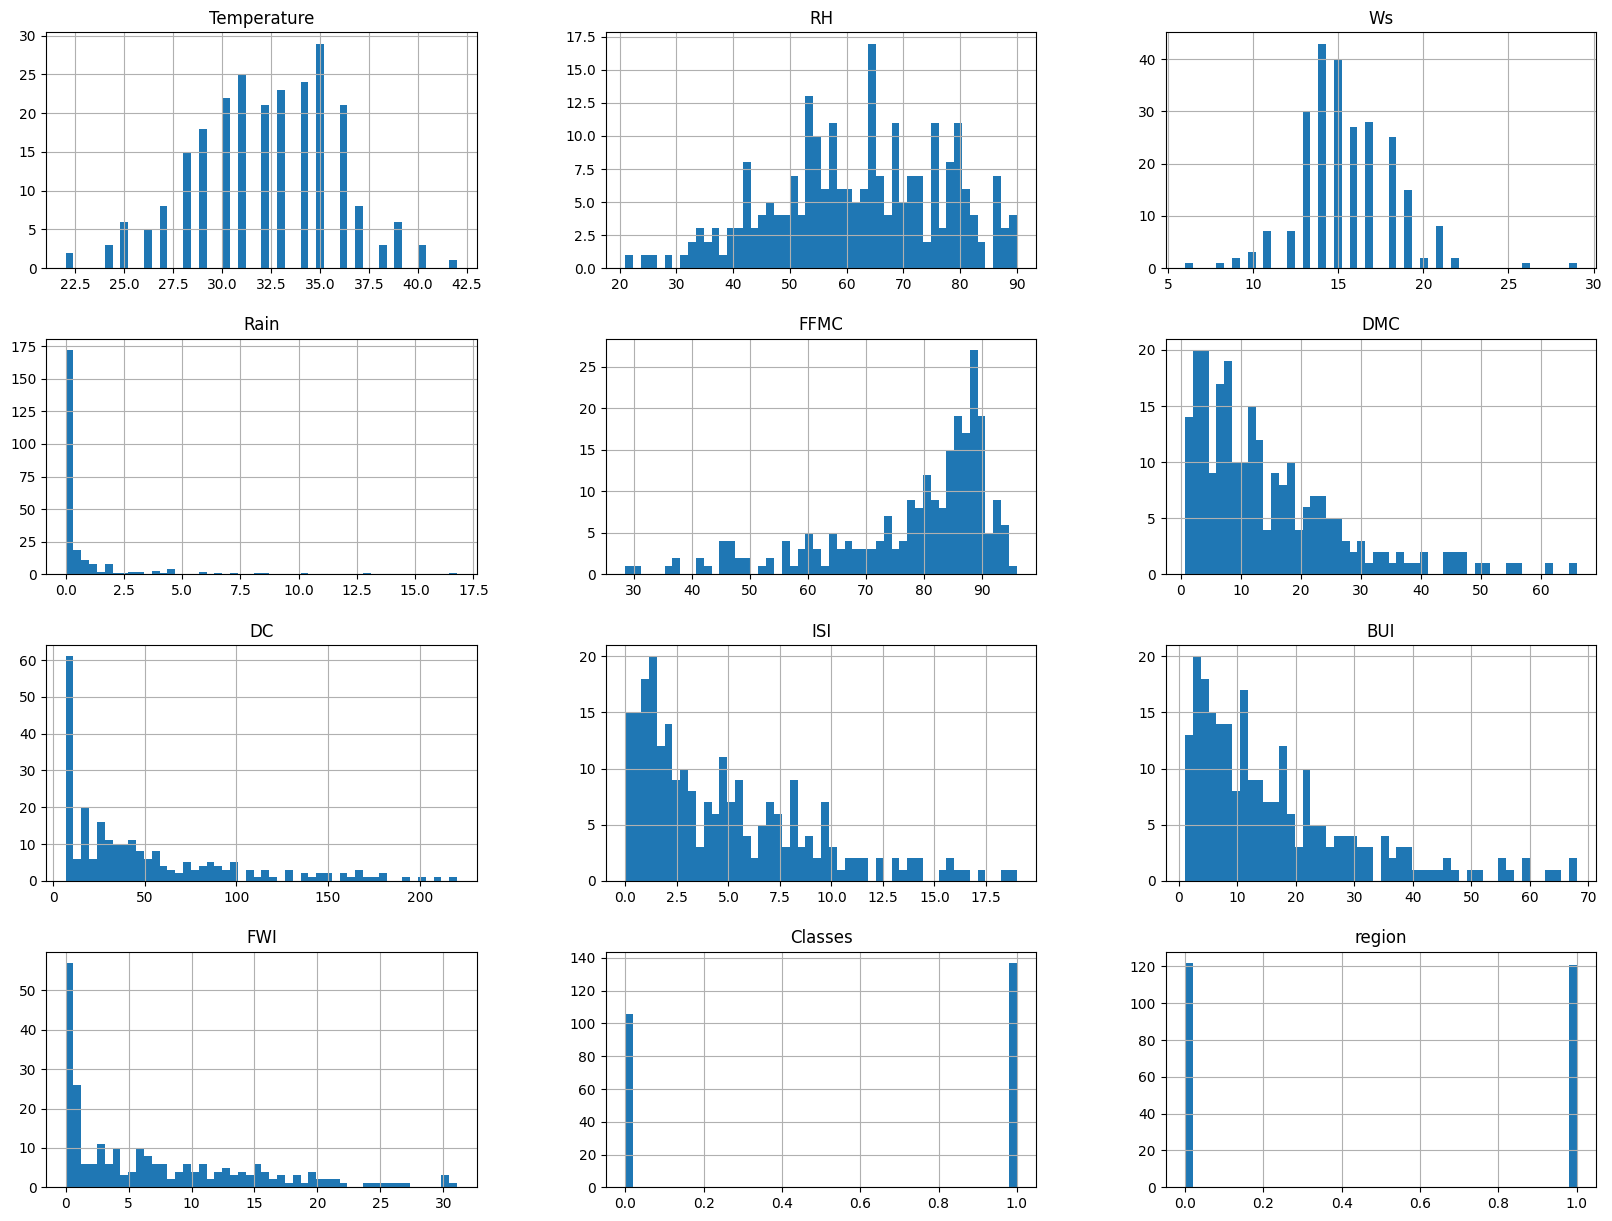

In [54]:
## plot density plot for all features

data_copy.hist(bins=50, figsize=(20,15))
plt.show()

In [35]:
## perventage with pie chart
percentage = data_copy["Classes"].value_counts(normalize=True)*100
percentage


Classes
1    56.378601
0    43.621399
Name: proportion, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

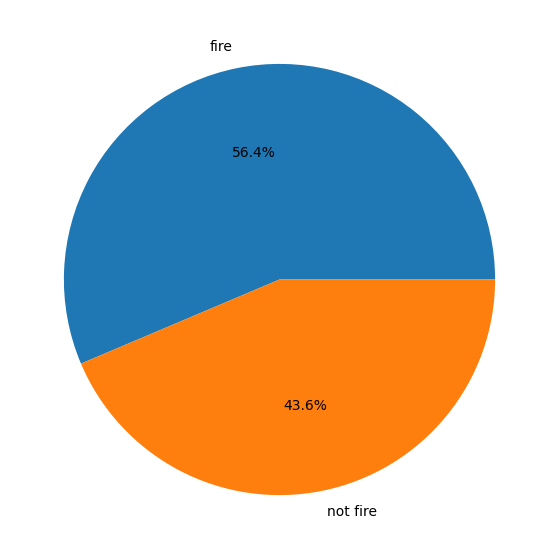

In [36]:
## ploting pie chart
labels = ["fire","not fire"]
plt.figure(figsize=(12,7))
plt.pie(percentage, labels = labels, autopct="%1.1f%%")
plt.show

In [10]:
## corelation
data_copy.corr()

,day,month,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
day,1.000000,-0.000369,0.097227,-0.076034,0.047812,-0.112523,0.224956,0.491514,0.527952,0.180543,0.517117,0.350781,0.202840,0.000821
month,-0.000369,1.000000,-0.056781,-0.041252,-0.039880,0.034822,0.017030,0.067943,0.126511,0.065608,0.085073,0.082639,0.024004,0.001857
Temperature,0.097227,-0.056781,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269555
RH,-0.076034,-0.041252,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682
Ws,0.047812,-0.039880,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160
Rain,-0.112523,0.034822,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013
FFMC,0.224956,0.017030,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241
DMC,0.491514,0.067943,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089
DC,0.527952,0.126511,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734
ISI,0.180543,0.065608,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.735197,0.263197


<Axes: >

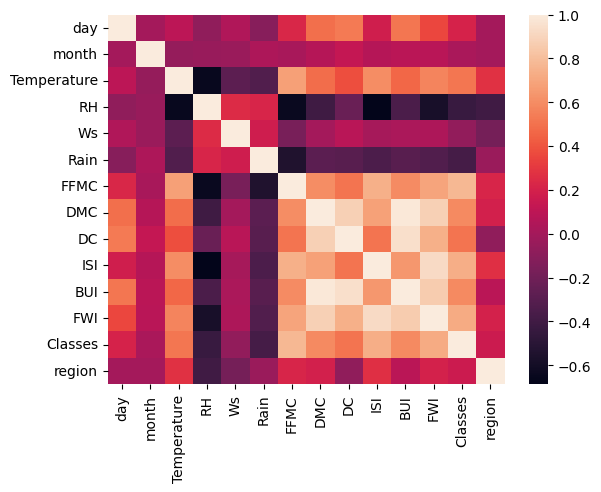

In [11]:
#lighter means more corelated 
sns.heatmap(data_copy.corr())

<Axes: xlabel='FWI'>

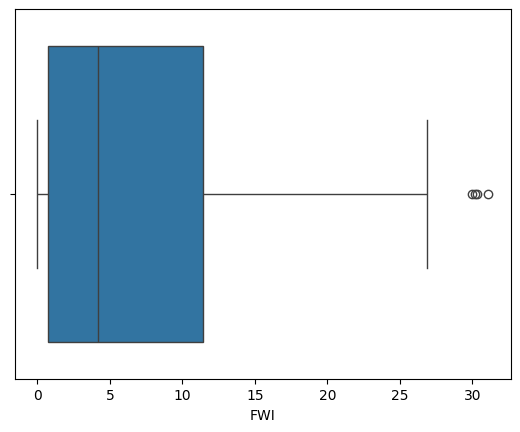

In [39]:
#boxplots
sns.boxplot(x=data_copy["FWI"])

<Axes: xlabel='Temperature'>

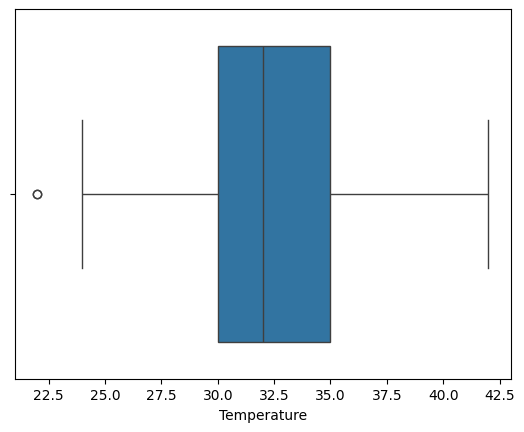

In [40]:
sns.boxplot(x=data_copy["Temperature"])

Text(0.5, 1.0, 'fire analysis of sidi-bel region')

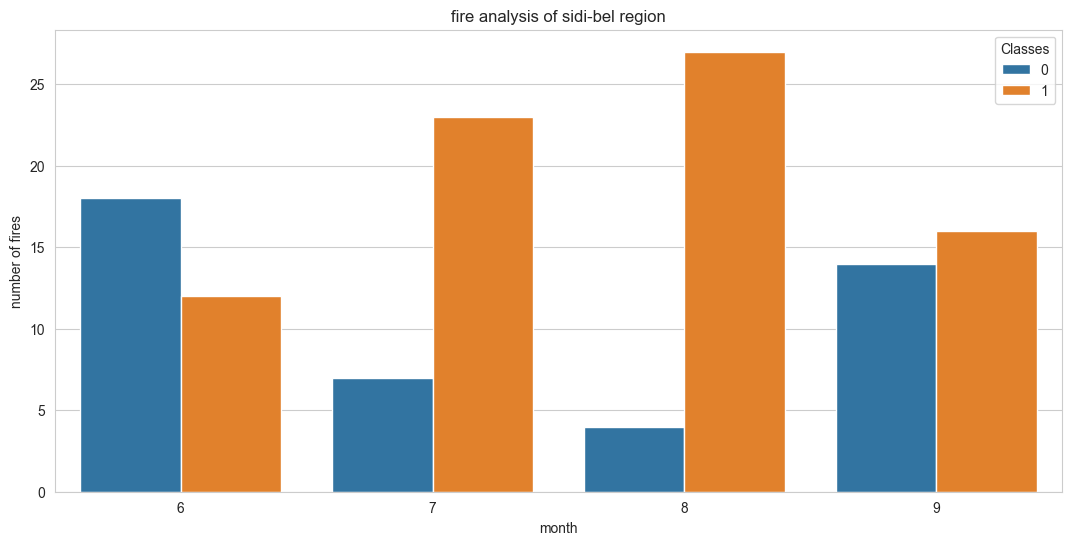

In [51]:
#for sidi-bel region
df_sidibel = data_copy.loc[data_copy["region"]==1]
plt.figure(figsize=(13,6))
sns.set_style("whitegrid")
sns.countplot(x="month",hue = "Classes",data=df_sidibel)
plt.ylabel("number of fires")
plt.xlabel("month")
plt.title("fire analysis of sidi-bel region")


Text(0.5, 1.0, 'fire analysis of brajaia region')

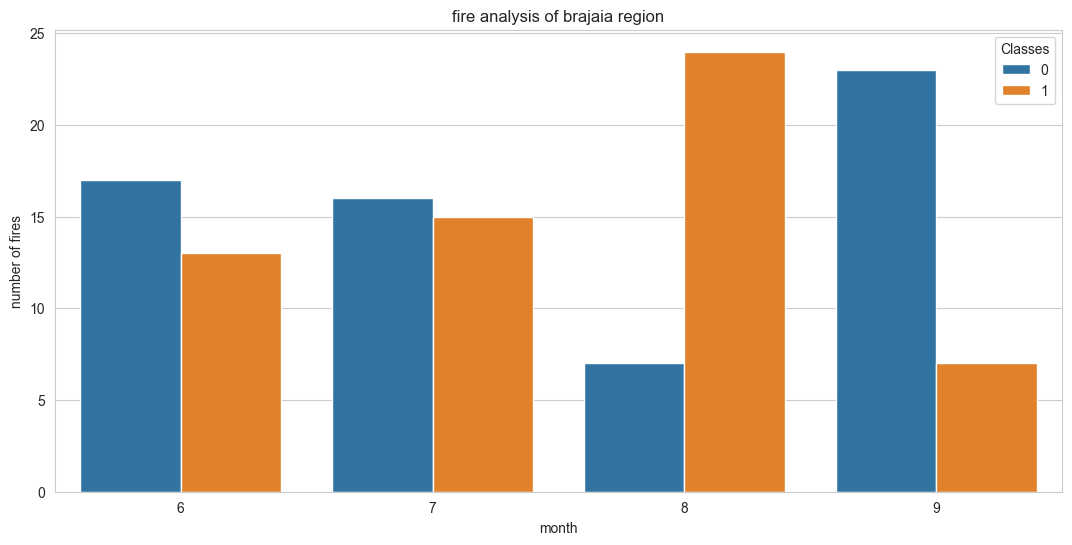

In [53]:
#for brajaia region
df_brajaia = data_copy.loc[data_copy["region"]==0]
plt.subplots(figsize=(13,6))
sns.set_style("whitegrid")
sns.countplot(x="month",hue = "Classes",data=df_brajaia)
plt.ylabel("number of fires")
plt.xlabel("month")
plt.title("fire analysis of brajaia region")


# Feature engineering

In [12]:
df = pd.read_csv("../data/data_cleaned.csv")

In [55]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [13]:
df = df.drop(["month","day","year"],axis=1)

In [14]:
df["Classes"] = np.where(df["Classes"].str.contains("not fire"),0,1)

In [15]:
df["Classes"].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [16]:
x = df.drop("FWI",axis = 1)
y = df["FWI"]

In [17]:
x.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [18]:
y.head()

0    0.5
1    0.4
2    0.1
3    0.0
4    0.5
Name: FWI, dtype: float64

In [19]:
## train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state = 42)

In [20]:
x_test.shape,x_train.shape


((61, 11), (182, 11))

In [21]:
#feature selection based on corelation
x.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,region
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.516015,0.269555
RH,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.432161,-0.402682
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,-0.069964,-0.181160
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.379097,-0.040013
FFMC,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.769492,0.222241
DMC,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.585658,0.192089
DC,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.511123,-0.078734
ISI,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.735197,0.263197
BUI,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.586639,0.089408
Classes,0.516015,-0.432161,-0.069964,-0.379097,0.769492,0.585658,0.511123,0.735197,0.586639,1.000000,0.162347


<Axes: >

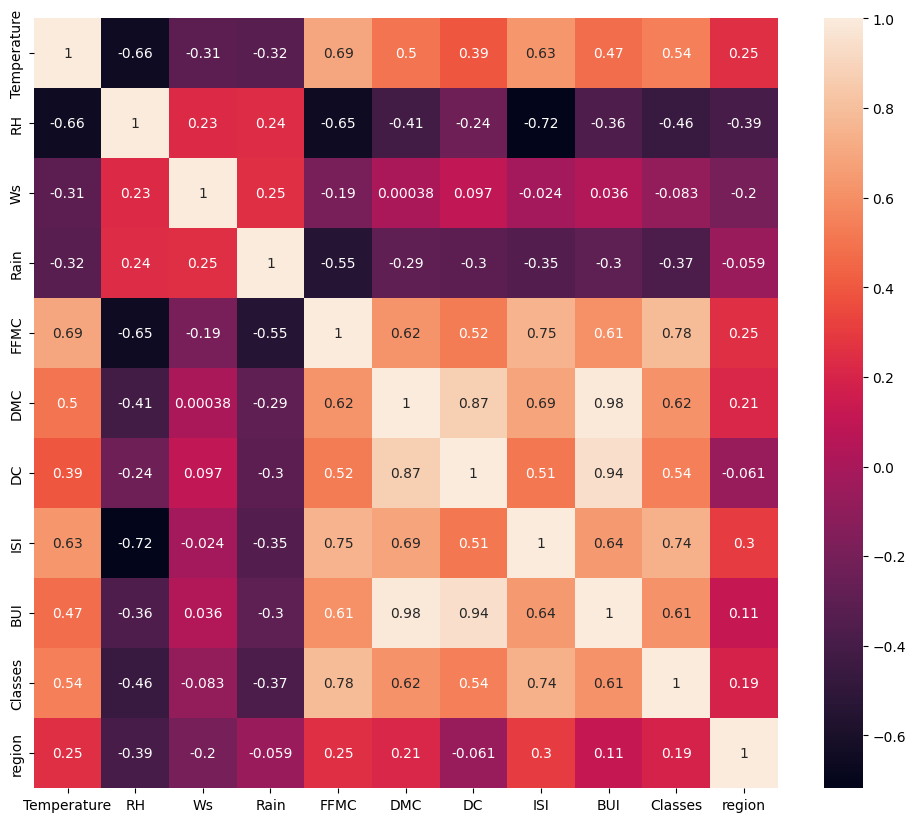

In [22]:
plt.figure(figsize=(12,10))
corr = x_train.corr()
sns.heatmap(corr,annot=True)

In [23]:
def correlation(dataset,treshhold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j])>treshhold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [24]:
## tresh hold will select by domain expert
correlation(x_train,0.85)

{'BUI', 'DC'}

In [25]:
# drop features
x_train = x_train.drop(['BUI', 'DC'],axis = 1)
x_test = x_test.drop(['BUI', 'DC'],axis = 1)

#### feature Scaling and Standardization

In [26]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)

In [27]:
x_test_scaled = scaler.transform(x_test)

Text(0.5, 1.0, 'after scaling')

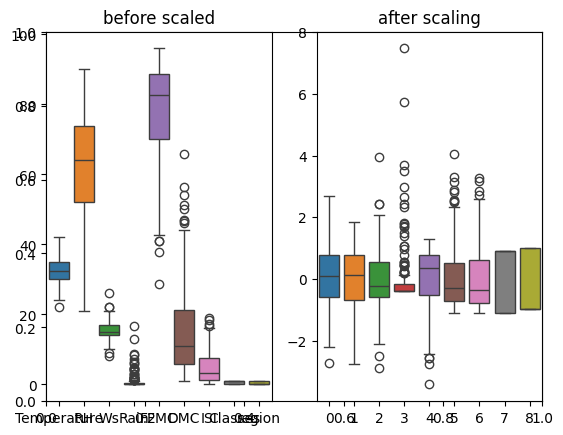

In [28]:
plt.subplot()
plt.subplot(1,2,1)
sns.boxplot(data=x_train)
plt.title("before scaled")
plt.subplot(1,2,2)
sns.boxplot(data=x_train_scaled)
plt.title("after scaling")

# Linear regression

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score
linear_regression_model = LinearRegression()
linear_regression_model.fit(x_train_scaled,y_train)



,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [72]:
y_pred = linear_regression_model.predict(x_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print(f"mean absolute error is {mae} and r2 score is {score}")

mean absolute error is 0.5468236465249978 and r2 score is 0.9847657384266951


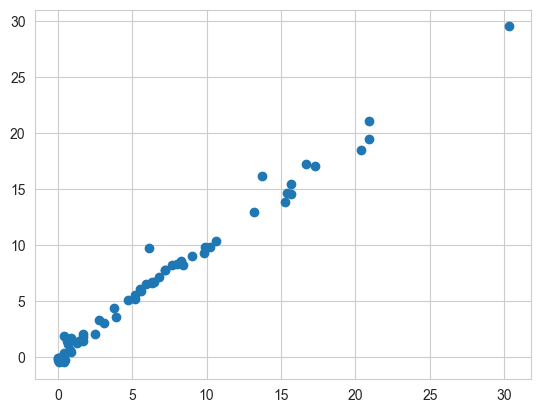

In [73]:
plt.scatter(y_test, y_pred)

## Lasso regression
helps to avoid overfitting


In [30]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error,r2_score
lasso_regression_model = Lasso()
lasso_regression_model.fit(x_train_scaled,y_train)
y_pred = lasso_regression_model.predict(x_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print(f"mean absolute error is {mae} and r2 score is {score}")

mean absolute error is 1.133175994914409 and r2 score is 0.9492020263112388


## Ridge regression
helps to feature selection

In [75]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error,r2_score
ridge_regression_model = Ridge()
ridge_regression_model.fit(x_train_scaled,y_train)
y_pred = ridge_regression_model.predict(x_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print(f"mean absolute error is {mae} and r2 score is {score}")

mean absolute error is 0.5642305340105715 and r2 score is 0.9842993364555512


## elastic net
Combination of ridge and lasso

In [76]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error,r2_score
elastic_net_model = ElasticNet()
elastic_net_model.fit(x_train_scaled,y_train)
y_pred = elastic_net_model.predict(x_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print(f"mean absolute error is {mae} and r2 score is {score}")

mean absolute error is 1.8822353634896005 and r2 score is 0.8753460589519703


## Cross validation with lasso

In [31]:
from sklearn.linear_model import LassoCV

In [32]:
lassocv = LassoCV(cv=5)
lassocv.fit(x_train_scaled,y_train)

,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'
,fit_intercept,True
,precompute,'auto'
,max_iter,1000
,tol,0.0001
,copy_X,True
,cv,5
,verbose,False
,n_jobs,None


In [33]:
lassocv.alpha_

np.float64(0.05725391318234408)

In [34]:
lassocv.alphas_

array([7.05853002, 6.58280872, 6.13914944, 5.72539132, 5.33951911,
       4.97965339, 4.64404142, 4.33104857, 4.03915039, 3.76692517,
       3.51304702, 3.27627941, 3.05546914, 2.84954075, 2.65749124,
       2.47838523, 2.31135036, 2.15557308, 2.01029467, 1.87480753,
       1.74845178, 1.63061198, 1.52071419, 1.41822315, 1.32263965,
       1.23349817, 1.15036452, 1.0728338 , 1.00052839, 0.93309613,
       0.87020857, 0.81155943, 0.75686304, 0.705853  , 0.65828087,
       0.61391494, 0.57253913, 0.53395191, 0.49796534, 0.46440414,
       0.43310486, 0.40391504, 0.37669252, 0.3513047 , 0.32762794,
       0.30554691, 0.28495408, 0.26574912, 0.24783852, 0.23113504,
       0.21555731, 0.20102947, 0.18748075, 0.17484518, 0.1630612 ,
       0.15207142, 0.14182231, 0.13226397, 0.12334982, 0.11503645,
       0.10728338, 0.10005284, 0.09330961, 0.08702086, 0.08115594,
       0.0756863 , 0.0705853 , 0.06582809, 0.06139149, 0.05725391,
       0.05339519, 0.04979653, 0.04644041, 0.04331049, 0.04039

In [35]:
score = r2_score(y_test,lassocv.predict(x_test_scaled))

In [36]:
score

0.9820946715928275

In [41]:
import joblib

# Export the model
joblib.dump(lassocv, 'lassocv.pkl')

['lassocv.pkl']

## Cross validation with ridge

In [39]:
from sklearn.linear_model import RidgeCV
ridgecv = LassoCV(cv=5)
ridgecv.fit(x_train_scaled,y_train)
score = r2_score(y_test,ridgecv.predict(x_test_scaled))
print(score)

0.9820946715928275


In [42]:
joblib.dump(ridgecv, '../models/ridgecv.pkl')

['../models/ridgecv.pkl']

## cross validation with elastic net

In [43]:
from sklearn.linear_model import ElasticNetCV
elasticcv = ElasticNetCV(cv=5)
elasticcv.fit(x_train_scaled,y_train)
score = r2_score(y_test,elasticcv.predict(x_test_scaled))
print(score)

0.9814217587854941


In [44]:
joblib.dump(elasticcv, '../models/elasticcv.pkl')

['../models/elasticcv.pkl']